In [1]:
from heisenberg_hamiltonians import HeisenbergJ1J2
from spin_lattices import SpinLattice, KagomeLattice
import numpy as np
import matplotlib.pyplot as plt
from vmc_amplitude import get_csr_hamiltonian
from scipy.sparse import diags
import ising_glass_annealer as ising
from swo_validation_2023_09_14 import configs, default_config, get_setup, output_dir
import pandas as pd
import seaborn as sns

In [2]:
task_id = 43
lattice, system, _ = get_setup(task_id)

2023-09-21 21:26:12.424 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=18
2023-09-21 21:26:12.426 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-09-21 21:26:12.427 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-21 21:26:12.443 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 48620


In [11]:
system.get_eigenstates(1)
ground_state = system.get_ground_state()
output = []
for iteration in [9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119]:
    predicted_amplitudes = np.sqrt(np.load(output_dir / str(task_id) / f"log_prob_fn_{iteration}_predicted_probs.npy"))

    amplitude_overlap = predicted_amplitudes @ np.abs(ground_state)
    print(f"{amplitude_overlap=}")
    ising_hamiltonian_matrix = diags(predicted_amplitudes) @ get_csr_hamiltonian(system) @ diags(predicted_amplitudes)
    ising_hamiltonian = ising.Hamiltonian(exchange=ising_hamiltonian_matrix, field=np.zeros(ising_hamiltonian_matrix.shape[0]))
    reconstructed_signs = ising.bits_to_signs(ising.anneal(ising_hamiltonian)[0], ising_hamiltonian.exchange.shape[0])
    reconstructed_sign_overlap = np.abs(((reconstructed_signs * (np.sign(ground_state))) * ground_state ** 2).sum())
    print(f"{reconstructed_sign_overlap=}")
    output.append({"iteration": iteration, "amplitude_overlap": amplitude_overlap, "reconstructed_sign_overlap": reconstructed_sign_overlap})

amplitude_overlap=0.4840571643126686
reconstructed_sign_overlap=0.005510226804838806
amplitude_overlap=0.6080937089577584
reconstructed_sign_overlap=0.9530230053444743
amplitude_overlap=0.7147756291769682
reconstructed_sign_overlap=0.9871027503765895
amplitude_overlap=0.7862407064631023
reconstructed_sign_overlap=0.9880006878007659
amplitude_overlap=0.8258660136983814
reconstructed_sign_overlap=0.9887563597316352
amplitude_overlap=0.8497239398436527
reconstructed_sign_overlap=0.9879411071730876
amplitude_overlap=0.8632276528229063
reconstructed_sign_overlap=0.9837212216006241
amplitude_overlap=0.8684742268556844
reconstructed_sign_overlap=0.9841528651737599
amplitude_overlap=0.8684743884923746
reconstructed_sign_overlap=0.9837849942632639
amplitude_overlap=0.8649803536541263
reconstructed_sign_overlap=0.9847943658743049
amplitude_overlap=0.860053760672178
reconstructed_sign_overlap=0.9856634150653354
amplitude_overlap=0.8528376783198324
reconstructed_sign_overlap=0.9861301727281044


/tmp/nix-shell.gJIUUm/ipykernel_781209/3484891665.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(pd.DataFrame(output).melt(id_vars=['iteration']), x='iteration', y='value', hue='variable', kind='line', style='variable', markers=['o'])
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


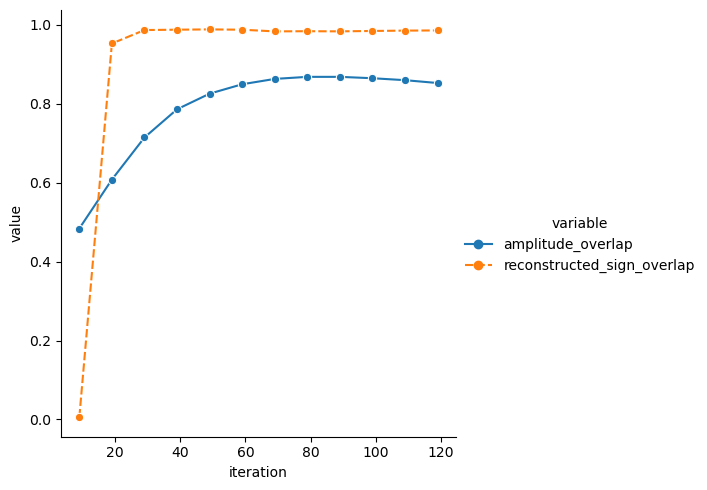

In [12]:
sns.relplot(pd.DataFrame(output).melt(id_vars=['iteration']), x='iteration', y='value', hue='variable', kind='line', style='variable', markers=['o'])

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


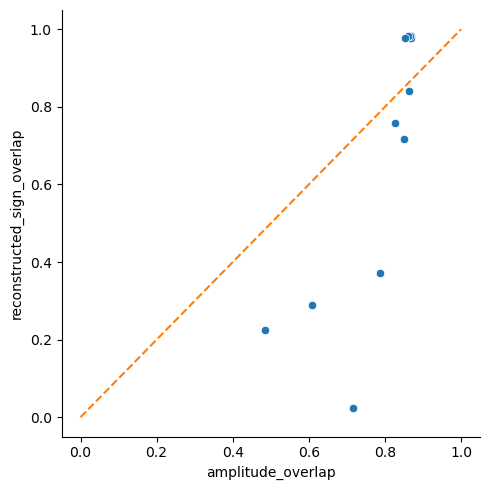

In [8]:
sns.relplot(pd.DataFrame(output), x='amplitude_overlap', y='reconstructed_sign_overlap', kind='scatter')
plt.plot([0, 1], [0, 1], color='C1', linestyle='--')

In [13]:
(np.abs(ground_state) ** 2).sum()

1.000000000000003

0.8249527386305544